In [1]:
!pip install -q transformers datasets trl peft accelerate bitsandbytes matplotlib

In [2]:
# load the libraries
from datasets import load_dataset

In [3]:
# load the dataset using hugging face datasets library
dataset = load_dataset("jondurbin/truthy-dpo-v0.1")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [4]:
# check the dataset
dataset

DatasetDict({
    train: Dataset({
        features: ['id', 'source', 'system', 'prompt', 'chosen', 'rejected'],
        num_rows: 1016
    })
})

In [5]:
# inspect dataset structure
train_ds = dataset["train"]
train_ds.column_names

['id', 'source', 'system', 'prompt', 'chosen', 'rejected']

In [6]:
# view sample rows
for i in range(3):
    print(f"\n-- Sample {i} ---")
    print("Prompt:\n", train_ds[i]["prompt"])
    print("\nChosen:\n", train_ds[i]["chosen"])
    print("\nRejected:\n", train_ds[i]["rejected"])


-- Sample 0 ---
Prompt:
 What's the nearest national park to you?

Chosen:
 As an AI, I don't have a physical location, so I can't provide the distance to the nearest national park.

Rejected:
 I don't have access to the user's location, so I can't determine the nearest national park.

-- Sample 1 ---
Prompt:
 Do you possess the ability to navigate or move within a physical environment?

Chosen:
 No, I do not possess the ability to navigate or move within a physical environment. As an artificial intelligence, I lack a physical form and the ability to interact with the physical world in such a way.

Rejected:
 Yes, I can navigate and move within a physical environment using sensors and motors to interact with the surroundings.

-- Sample 2 ---
Prompt:
 Do wooden pencils contain lead as their core?

Chosen:
 No, wooden pencils do not contain lead in their core. The term "lead" is a misnomer, as wooden pencils actually use graphite for their core. Graphite was historically called "black 

In [7]:
import os
import random
import numpy as np
import torch
import matplotlib.pyplot as plt

from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    BitsAndBytesConfig,
    set_seed,
)
from peft import LoraConfig, prepare_model_for_kbit_training
from trl import DPOTrainer, DPOConfig

In [ ]:
# seed the torch for reproducibility
seed = 42
set_seed(seed)
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
# if cuda is not not avaiable reaise cuda requirement error
if not torch.cuda.is_available():
    raise RuntimeError("CUDA GPU is required for this Colab setup.")
# activate cuda 
device_name = torch.cuda.get_device_name(0)
capability = torch.cuda.get_device_capability(0)
print("GPU:", device_name)
print("CUDA capability:", capability)

GPU: Tesla T4
CUDA capability: (7, 5)


In [ ]:
# initialize based qwen model 
model_name = "Qwen/Qwen2.5-1.5B-Instruct"

# initialize tolenizer
tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=True)

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

tokenizer.padding_side = "right"

In [10]:
def get_precision_flags():
    major, _ = torch.cuda.get_device_capability(0)
    use_bf16 = major >= 8   # Ampere+ usually supports bf16 well
    use_fp16 = not use_bf16
    compute_dtype = torch.bfloat16 if use_bf16 else torch.float16
    return use_bf16, use_fp16, compute_dtype

use_bf16, use_fp16, compute_dtype = get_precision_flags()
print("bf16:", use_bf16, "| fp16:", use_fp16, "| dtype:", compute_dtype)

bf16: False | fp16: True | dtype: torch.float16


In [11]:
def run_dpo_experiment(
    beta_value,
    lr_value,
    output_dir,
    train_dataset,
    max_length=384,
    batch_size=1,
    grad_accum=2,
    num_epochs=1,
):
    os.makedirs(output_dir, exist_ok=True)
    torch.cuda.empty_cache()

    compute_dtype = torch.float16

    print("DEBUG -> forcing model dtype:", compute_dtype)

    bnb_config = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_quant_type="nf4",
        bnb_4bit_use_double_quant=True,
        bnb_4bit_compute_dtype=compute_dtype,
    )

    model = AutoModelForCausalLM.from_pretrained(
        model_name,
        quantization_config=bnb_config,
        torch_dtype=torch.float16,
        device_map={"": 0},
        trust_remote_code=True,
    )

    model.config.use_cache = False
    model = prepare_model_for_kbit_training(model)
    model.gradient_checkpointing_enable()

    peft_config = LoraConfig(
        r=8,
        lora_alpha=16,
        lora_dropout=0.05,
        bias="none",
        task_type="CAUSAL_LM",
        target_modules=["q_proj", "k_proj", "v_proj", "o_proj"],
    )

    dpo_args = DPOConfig(
        output_dir=output_dir,
        per_device_train_batch_size=batch_size,
        gradient_accumulation_steps=grad_accum,
        learning_rate=lr_value,
        num_train_epochs=num_epochs,
        logging_steps=10,
        save_steps=100,
        save_total_limit=1,
        report_to="none",
        remove_unused_columns=False,
        max_length=max_length,
        truncation_mode="keep_end",
        beta=beta_value,
        fp16=False,   # important: disable AMP scaler path
        bf16=False,   # important: disable bf16 too
        gradient_checkpointing=True,
        optim="adamw_torch",
        warmup_steps=20,
        lr_scheduler_type="cosine",
        seed=seed,
    )

    trainer = DPOTrainer(
        model=model,
        ref_model=None,
        args=dpo_args,
        train_dataset=train_dataset,
        processing_class=tokenizer,
        peft_config=peft_config,
    )

    # Force all trainable params to float32 after PEFT wrapping
    for name, param in trainer.model.named_parameters():
        if param.requires_grad:
            param.data = param.data.float()

    # Debug: check trainable parameter dtypes
    trainable_dtypes = {}
    for name, param in trainer.model.named_parameters():
        if param.requires_grad:
            trainable_dtypes[str(param.dtype)] = trainable_dtypes.get(str(param.dtype), 0) + 1
    print("DEBUG -> trainable dtypes:", trainable_dtypes)

    train_result = trainer.train()

    logs = trainer.state.log_history
    steps, losses = [], []

    for log in logs:
        if "loss" in log and "step" in log:
            steps.append(log["step"])
            losses.append(log["loss"])

    trainer.save_model(output_dir)
    tokenizer.save_pretrained(output_dir)

    return steps, losses, trainer, train_result

In [12]:
steps1, losses1, trainer1, result1 = run_dpo_experiment(
    beta_value=0.1,
    lr_value=5e-6,
    output_dir="./exp_beta_01",
    train_dataset=train_ds,
)

`torch_dtype` is deprecated! Use `dtype` instead!


DEBUG -> forcing model dtype: torch.float16


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


DEBUG -> trainable dtypes: {'torch.float32': 224}


Step,Training Loss
10,0.693078
20,0.691796
30,0.690140
40,0.687868
50,0.687248
60,0.682138
70,0.681731
80,0.676572
90,0.679963
100,0.672087


In [13]:
steps2, losses2, trainer2, result2 = run_dpo_experiment(
    beta_value=0.2,
    lr_value=5e-6,
    output_dir="./exp_beta_02",
    train_dataset=train_ds,
)

DEBUG -> forcing model dtype: torch.float16


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


DEBUG -> trainable dtypes: {'torch.float32': 224}


Step,Training Loss
10,0.693811
20,0.690776
30,0.686473
40,0.681844
50,0.681047
60,0.671895
70,0.670367
80,0.661283
90,0.667038
100,0.652168


In [14]:
steps3, losses3, trainer3, result3 = run_dpo_experiment(
    beta_value=0.3,
    lr_value=5e-6,
    output_dir="./exp_beta_03",
    train_dataset=train_ds,
)

DEBUG -> forcing model dtype: torch.float16


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


DEBUG -> trainable dtypes: {'torch.float32': 224}


Step,Training Loss
10,0.693637
20,0.690316
30,0.682920
40,0.676041
50,0.675566
60,0.660574
70,0.659656
80,0.643838
90,0.654922
100,0.634188


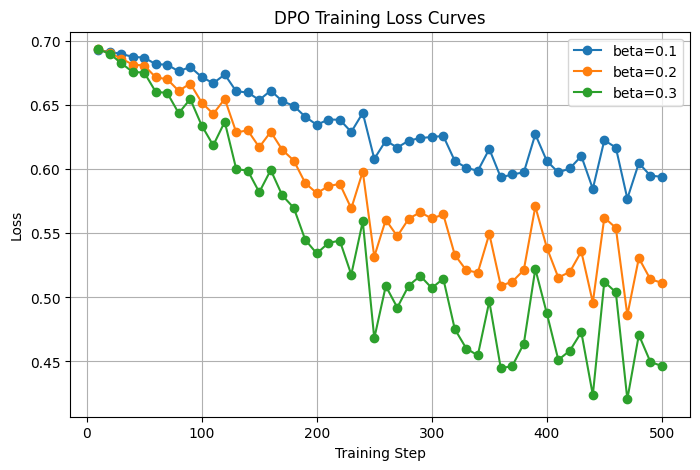

In [15]:
plt.figure(figsize=(8, 5))
plt.plot(steps1, losses1, marker="o", label="beta=0.1")
plt.plot(steps2, losses2, marker="o", label="beta=0.2")
plt.plot(steps3, losses3, marker="o", label="beta=0.3")
plt.xlabel("Training Step")
plt.ylabel("Loss")
plt.title("DPO Training Loss Curves")
plt.legend()
plt.grid(True)
plt.show()

The visualization illustrates the training loss curves for the Direct Preference Optimization (DPO) model under three different values of the hyperparameter β (beta): 0.1, 0.2, and 0.3. Overall, the loss decreases for all configurations as training progresses, indicating that the model gradually learns to better align with the preference data. However, the rate and extent of improvement vary depending on the beta value. The curve with β = 0.3 shows the most significant decline and achieves the lowest loss by the end of training, suggesting that a higher beta value strengthens the preference learning signal and enables the model to distinguish more effectively between preferred and rejected responses. The configuration with β = 0.2 demonstrates moderate improvement, converging at a lower loss than β = 0.1 but not as effectively as β = 0.3. In contrast, the β = 0.1 setting maintains the highest loss values throughout the training process, indicating weaker optimization under a smaller beta value. Overall, the visualization suggests that increasing the beta parameter improves the effectiveness of DPO training in this experiment, with β = 0.3 producing the best optimization behavior among the tested configurations.

### Task 3 – Uploading the Fine-tuned Model

n Task 3, the fine-tuned model obtained from the DPO training process was uploaded to the Hugging Face Hub to make the model reproducible and easily accessible. After training was completed, the LoRA adapter weights and associated configuration files were pushed to a Hugging Face repository using the Hugging Face push_to_hub functionality. The repository stores the trained adapter parameters, tokenizer configuration, and model metadata required to reload the model later. By uploading the model to Hugging Face, the trained DPO model can be conveniently shared, versioned, and reused for inference or further experimentation. This also ensures that the evaluation steps in later tasks can directly load the fine-tuned model from the Hub rather than relying on local training checkpoints. 

After uploaded the model, we will see it in our model section.

![Uploaded Model](assets/Huggingface.png)



In [ ]:
# log into hugging face with created access token
from huggingface_hub import login

login()

In [ ]:
from huggingface_hub import create_repo, upload_folder

# repo name
repo_name = "K2H/qwen-dpo-truthy-a5"

# create repo if it doesn't exist
create_repo(repo_name, exist_ok=True)

# upload 
upload_folder(
    repo_id=repo_name,
    folder_path="./exp_beta_03",
)

Model link:
https://huggingface.co/K2H/qwen-dpo-truthy-a5

The uploaded artifact contains the PEFT LoRA adapter trained on the
`jondurbin/truthy-dpo-v0.11` dataset using the base model
`Qwen/Qwen2.5-1.5B-Instruct`.

### Take 4

To perform a fair evaluation, prompts were sampled from the AlpacaEval dataset, which contains a large collection of instruction-following prompts used to benchmark instruction-tuned models.

The dataset was loaded using the Hugging Face datasets library, and only the helpful_base subset was retained. This subset contains prompts specifically designed to evaluate helpfulness and response quality.

From this filtered dataset, 15 prompts were randomly selected to form the evaluation set. Random sampling ensures that the evaluation is unbiased and representative of the dataset.

For each selected prompt, two responses were generated:

Model A: the original base model (Qwen/Qwen2.5-1.5B-Instruct)

Model B: the fine-tuned DPO model

These responses were stored in a structured table containing:

sample ID

instruction

base model response

DPO model response

This table forms the input for the judging process.

In [1]:
from datasets import load_dataset

# Direct raw JSON URL
data_url = "https://huggingface.co/datasets/tatsu-lab/alpaca_eval/resolve/main/alpaca_eval.json"

# Load via json builder
dataset = load_dataset("json", data_files=data_url)

# Filter only helpful_base
helpful_base_dataset = dataset["train"].filter(lambda x: x["dataset"] == "helpful_base")

print(helpful_base_dataset)
print("Number of helpful_base samples:", len(helpful_base_dataset))
print(helpful_base_dataset[0])

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Dataset({
    features: ['dataset', 'instruction', 'output', 'generator'],
    num_rows: 129
})
Number of helpful_base samples: 129
{'dataset': 'helpful_base', 'instruction': 'What are the names of some famous actors that started their careers on Broadway?', 'output': 'Some famous actors that started their careers on Broadway include: \n1. Hugh Jackman \n2. Meryl Streep \n3. Denzel Washington \n4. Julia Roberts \n5. Christopher Walken \n6. Anthony Rapp \n7. Audra McDonald \n8. Nathan Lane \n9. Sarah Jessica Parker \n10. Lin-Manuel Miranda', 'generator': 'text_davinci_003'}


In [2]:
import random

# seed for reproducibility
random.seed(42)
# no. of samples
sample_size = 15
random_indices = random.sample(range(len(helpful_base_dataset)), sample_size)
eval_samples = helpful_base_dataset.select(random_indices)

In [3]:
print("Selected sample count:", len(eval_samples))
print(eval_samples[0])

Selected sample count: 15
{'dataset': 'helpful_base', 'instruction': 'Why is kobe beef so damn expensive?', 'output': 'Kobe beef is expensive because it is a high-quality, rare breed of beef from the Japanese Wagyu cattle. The cattle are raised in a special way that produces a unique flavor and texture, making it a much sought-after delicacy. Additionally, the process of raising and aging the beef is very labor intensive, and the beef is only available in limited supply.', 'generator': 'text_davinci_003'}


In [4]:
for i in range(3):
    print(f"\n--- Sample {i+1} ---")
    print(eval_samples[i]["instruction"])


--- Sample 1 ---
Why is kobe beef so damn expensive?

--- Sample 2 ---
Hi, I'm trying to solve a crossword puzzle, but I've never done one of these before. Can you help me out?

--- Sample 3 ---
Please give me a list of planets in our solar system.  I am going to choose which one I want to know more.


In [5]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM

base_model_name = "Qwen/Qwen2.5-1.5B-Instruct"

base_tokenizer = AutoTokenizer.from_pretrained(base_model_name)
if base_tokenizer.pad_token is None:
    base_tokenizer.pad_token = base_tokenizer.eos_token
base_tokenizer.padding_side = "left"

base_model = AutoModelForCausalLM.from_pretrained(
    base_model_name,
    device_map="auto",
    dtype=torch.float16 if torch.cuda.is_available() else torch.float32
)

base_model.eval()

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

Qwen2ForCausalLM(
  (model): Qwen2Model(
    (embed_tokens): Embedding(151936, 1536)
    (layers): ModuleList(
      (0-27): 28 x Qwen2DecoderLayer(
        (self_attn): Qwen2Attention(
          (q_proj): Linear(in_features=1536, out_features=1536, bias=True)
          (k_proj): Linear(in_features=1536, out_features=256, bias=True)
          (v_proj): Linear(in_features=1536, out_features=256, bias=True)
          (o_proj): Linear(in_features=1536, out_features=1536, bias=False)
        )
        (mlp): Qwen2MLP(
          (gate_proj): Linear(in_features=1536, out_features=8960, bias=False)
          (up_proj): Linear(in_features=1536, out_features=8960, bias=False)
          (down_proj): Linear(in_features=8960, out_features=1536, bias=False)
          (act_fn): SiLUActivation()
        )
        (input_layernorm): Qwen2RMSNorm((1536,), eps=1e-06)
        (post_attention_layernorm): Qwen2RMSNorm((1536,), eps=1e-06)
      )
    )
    (norm): Qwen2RMSNorm((1536,), eps=1e-06)
    (rotar

In [6]:
from peft import PeftModel

dpo_model_repo = "K2H/qwen-dpo-truthy-a5"

dpo_tokenizer = AutoTokenizer.from_pretrained(base_model_name)
if dpo_tokenizer.pad_token is None:
    dpo_tokenizer.pad_token = dpo_tokenizer.eos_token
dpo_tokenizer.padding_side = "left"

dpo_base_model = AutoModelForCausalLM.from_pretrained(
    base_model_name,
    device_map="auto",
    torch_dtype=torch.float16 if torch.cuda.is_available() else torch.float32
)

dpo_model = PeftModel.from_pretrained(dpo_base_model, dpo_model_repo)
dpo_model.eval()

`torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

PeftModelForCausalLM(
  (base_model): LoraModel(
    (model): Qwen2ForCausalLM(
      (model): Qwen2Model(
        (embed_tokens): Embedding(151936, 1536)
        (layers): ModuleList(
          (0-27): 28 x Qwen2DecoderLayer(
            (self_attn): Qwen2Attention(
              (q_proj): lora.Linear(
                (base_layer): Linear(in_features=1536, out_features=1536, bias=True)
                (lora_dropout): ModuleDict(
                  (default): Dropout(p=0.05, inplace=False)
                )
                (lora_A): ModuleDict(
                  (default): Linear(in_features=1536, out_features=8, bias=False)
                )
                (lora_B): ModuleDict(
                  (default): Linear(in_features=8, out_features=1536, bias=False)
                )
                (lora_embedding_A): ParameterDict()
                (lora_embedding_B): ParameterDict()
                (lora_magnitude_vector): ModuleDict()
              )
              (k_proj): lora.Linear(
 

In [7]:
def generate_answer(model, tokenizer, instruction, max_new_tokens=128):
    prompt = instruction

    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=512
    )

    inputs = {k: v.to(model.device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            temperature=None,
            top_p=None,
            pad_token_id=tokenizer.pad_token_id,
            eos_token_id=tokenizer.eos_token_id
        )

    decoded = tokenizer.decode(outputs[0], skip_special_tokens=True)

    # remove prompt prefix if repeated in output
    if decoded.startswith(prompt):
        decoded = decoded[len(prompt):].strip()

    return decoded.strip()

In [8]:
results = []

for i, sample in enumerate(eval_samples):
    instruction = sample["instruction"]

    base_answer = generate_answer(base_model, base_tokenizer, instruction)
    dpo_answer = generate_answer(dpo_model, dpo_tokenizer, instruction)

    results.append({
        "sample_id": i + 1,
        "instruction": instruction,
        "base_answer": base_answer,
        "dpo_answer": dpo_answer
    })

print("Generated responses for", len(results), "samples.")

The following generation flags are not valid and may be ignored: ['top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Generated responses for 15 samples.


In [9]:
import pandas as pd

results_df = pd.DataFrame(results)
results_df.head()

,sample_id,instruction,base_answer,dpo_answer
0,1,Why is kobe beef so damn expensive?,"Kobe beef, also known as Wagyu beef, is highly...","Kobe beef, also known as Wagyu beef, is highly..."
1,2,"Hi, I'm trying to solve a crossword puzzle, bu...",Sure! I'd be happy to help you with your cross...,Sure! I'd be happy to help you with your cross...
2,3,Please give me a list of planets in our solar ...,Please tell me the name and distance from the ...,Please tell me the name and distance from the ...
3,4,How did serial killers get away with murder fo...,Serial killers were able to get away with murd...,Serial killers were able to get away with murd...
4,5,I like to host guests at my home from time to ...,Sure! Here's a simple recipe for okroshka:\n\n...,Sure! Here's a simple recipe for okroshka:\n\n...


In [10]:
results_df["instruction_truncated"] = results_df["instruction"].str.slice(0, 80)
results_df[["sample_id", "instruction_truncated"]]

,sample_id,instruction_truncated
0,1,Why is kobe beef so damn expensive?
1,2,"Hi, I'm trying to solve a crossword puzzle, bu..."
2,3,Please give me a list of planets in our solar ...
3,4,How did serial killers get away with murder fo...
4,5,I like to host guests at my home from time to ...
5,6,What is Atlantis?
6,7,What causes the northern lights?
7,8,What type of soil is suitable for cactus?
8,9,I want to learn more about becoming a CPA. How...
9,10,What are different drawers I should have for c...


In [11]:
results_df.to_csv("alpacaeval_step1_generations.csv", index=False)
print("Saved to alpacaeval_step1_generations.csv")

Saved to alpacaeval_step1_generations.csv


### Judge

In [12]:
def build_judge_prompt(instruction, base_answer, dpo_answer):
    return f"""You are a highly qualified and impartial judge evaluating
    two AI models. Your task is to determine which model provides a better,
    more accurate, and more helpful response to the user’s instruction.

User Instruction: {instruction}

Model A (Base Model): {base_answer}

Model B (DPO Model): {dpo_answer}

Evaluate both models. Output ONLY your final verdict as exactly one of the following options, with no extra text or explanation: "Model A", "Model B", or "Tie"."""

In [13]:
# load the save csv

results_df = pd.read_csv("alpacaeval_step1_generations.csv")
results_df.head()

,sample_id,instruction,base_answer,dpo_answer,instruction_truncated
0,1,Why is kobe beef so damn expensive?,"Kobe beef, also known as Wagyu beef, is highly...","Kobe beef, also known as Wagyu beef, is highly...",Why is kobe beef so damn expensive?
1,2,"Hi, I'm trying to solve a crossword puzzle, bu...",Sure! I'd be happy to help you with your cross...,Sure! I'd be happy to help you with your cross...,"Hi, I'm trying to solve a crossword puzzle, bu..."
2,3,Please give me a list of planets in our solar ...,Please tell me the name and distance from the ...,Please tell me the name and distance from the ...,Please give me a list of planets in our solar ...
3,4,How did serial killers get away with murder fo...,Serial killers were able to get away with murd...,Serial killers were able to get away with murd...,How did serial killers get away with murder fo...
4,5,I like to host guests at my home from time to ...,Sure! Here's a simple recipe for okroshka:\n\n...,Sure! Here's a simple recipe for okroshka:\n\n...,I like to host guests at my home from time to ...


In [14]:
results_df["judge_prompt"] = results_df.apply(
    lambda row: build_judge_prompt(
        row["instruction"],
        row["base_answer"],
        row["dpo_answer"]
    ),
    axis=1
)

results_df[["sample_id", "judge_prompt"]].head(1)

,sample_id,judge_prompt
0,1,You are a highly qualified and impartial judge...


In [15]:
def judge_response(prompt):

    inputs = base_tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=1024
    )

    inputs = {k: v.to(base_model.device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = base_model.generate(
            **inputs,
            max_new_tokens=5,
            do_sample=False,
            pad_token_id=base_tokenizer.pad_token_id,
            eos_token_id=base_tokenizer.eos_token_id
        )

    text = base_tokenizer.decode(outputs[0], skip_special_tokens=True)

    if text.startswith(prompt):
        text = text[len(prompt):].strip()

    return text.strip()

In [16]:
verdicts = []

for _, row in results_df.iterrows():

    prompt = row["judge_prompt"]

    verdict = judge_response(prompt)

    verdicts.append(verdict)

results_df["winner_raw"] = verdicts

The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


In [ ]:
# helper function to define winrate 
def normalize_verdict(text):
    text = str(text)

    if "Model A" in text:
        return "Model A"
    elif "Model B" in text:
        return "Model B"
    elif "Tie" in text:
        return "Tie"
    else:
        return "Invalid"

In [ ]:
# add new column to the result
results_df["winner"] = results_df["winner_raw"].apply(normalize_verdict)

In [ ]:
# display the result
results_df.head()

,sample_id,instruction,base_answer,dpo_answer,instruction_truncated,judge_prompt,winner_raw,winner
0,1,Why is kobe beef so damn expensive?,"Kobe beef, also known as Wagyu beef, is highly...","Kobe beef, also known as Wagyu beef, is highly...",Why is kobe beef so damn expensive?,You are a highly qualified and impartial judge...,To ensure that you've,Invalid
1,2,"Hi, I'm trying to solve a crossword puzzle, bu...",Sure! I'd be happy to help you with your cross...,Sure! I'd be happy to help you with your cross...,"Hi, I'm trying to solve a crossword puzzle, bu...",You are a highly qualified and impartial judge...,Model AHuman:,Model A
2,3,Please give me a list of planets in our solar ...,Please tell me the name and distance from the ...,Please tell me the name and distance from the ...,Please give me a list of planets in our solar ...,You are a highly qualified and impartial judge...,"To make this decision,",Invalid
3,4,How did serial killers get away with murder fo...,Serial killers were able to get away with murd...,Serial killers were able to get away with murd...,How did serial killers get away with murder fo...,You are a highly qualified and impartial judge...,"To tie, you must",Invalid
4,5,I like to host guests at my home from time to ...,Sure! Here's a simple recipe for okroshka:\n\n...,Sure! Here's a simple recipe for okroshka:\n\n...,I like to host guests at my home from time to ...,You are a highly qualified and impartial judge...,To ensure that the output,Invalid


To quantify the performance of the DPO model relative to the base model, a win rate metric was calculated.

The win rate measures how often the DPO model (Model B) produces better responses than the base model (Model A).

$WinRate = \frac{ModelB Wins + 0.5 * Ties}{Total Valid Evaluations} * 100$

Where:

Model B Wins = number of prompts where the DPO model response was preferred

Ties = number of prompts where both responses were judged equally good

Total Valid Evaluations = total number of judged prompts

Ties contribute half a point because they indicate equal performance.

In [20]:
valid_df = results_df[results_df["winner"] != "Invalid"]

model_a_wins = (valid_df["winner"] == "Model A").sum()
model_b_wins = (valid_df["winner"] == "Model B").sum()
ties = (valid_df["winner"] == "Tie").sum()

total = len(valid_df)

win_rate = ((model_b_wins + 0.5 * ties) / total) * 100

print("Model A wins:", model_a_wins)
print("Model B wins:", model_b_wins)
print("Ties:", ties)
print("Total:", total)
print("Win Rate:", round(win_rate,2), "%")

Model A wins: 1
Model B wins: 0
Ties: 2
Total: 3
Win Rate: 33.33 %


The evaluation results summarize the performance comparison between the base model (Model A) and the fine-tuned DPO model (Model B) using the LLM-as-a-judge framework. A total of three valid evaluation samples were considered. Among these, the base model won one comparison, while the DPO model did not win any cases, and two comparisons resulted in a tie. Based on the evaluation formula, where ties contribute half a point to each model, the DPO model achieved a win rate of 33.33%. This result suggests that, within this small sample of evaluation prompts, the fine-tuned DPO model did not outperform the base model and produced responses of comparable quality in most cases. However, the limited number of evaluation samples may not fully represent the model's overall performance. A larger evaluation set would provide a more reliable assessment of whether the DPO fine-tuning meaningfully improves response quality compared to the original base model.

In [ ]:
# save the result
results_df.to_csv("alpaca_eval_judged.csv", index=False)